# METODE B: ViT Fine-tuning (5-FOLD CV + TTA)
## ECG Myocardial Infarction Classification

### 🔧 Revisi Versi Ini:
| Aspek | Sebelum | Sesudah |
|-------|---------|---------|
| Split Data | Single train/val/test | **5-Fold Cross Validation** |
| Test Set | Dari split | **Dipisahkan dulu (20%), tidak disentuh selama CV** |
| Model Saved | 1 model | **5 model (satu per fold)** |
| Inference | 1x pada test | **5x inferensi (TTA) dengan model terbaik** |
| Patient-wise | ✅ | ✅ (tetap dijaga) |
| Synthetic data | Hanya di train | ✅ (tetap, hanya di train fold) |

### 📋 Alur:
1. Pisahkan test set (20% data real, berdasarkan pasien)
2. Sisa 80% → 5-Fold CV (patient-wise)
3. Setiap fold: train + val, simpan model terbaik per fold
4. Pilih model terbaik global (val loss terendah)
5. Inferensi 5x pada test set (1 baseline + 4 TTA)
6. Agregasi hasil (soft voting, hard voting, baseline) → pilih terbaik


## 1. Setup & Download Data

In [2]:
# Install dependencies
get_ipython().system('pip install -q gdown transformers pillow tqdm scikit-learn seaborn scipy')
get_ipython().system('apt-get update -qq && apt-get install -y -qq unrar')

import gdown
import subprocess
import os

# Download dari Google Drive
FILE_ID = "18IjP8_q8V0-m1tjvVRhJmBADCv4Iri8_"
RAR_PATH = "/workspace/png_segments.rar"
EXTRACT_TO = "/workspace/data/"

# Skip jika data sudah ada
if os.path.exists("/workspace/data/png_segments/NORM"):
    print("✅ Data sudah ada, skip download")
else:
    print("📥 Downloading... (tunggu ~10-15 menit)")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", RAR_PATH, quiet=True, fuzzy=True)

    if os.path.exists(RAR_PATH):
        size_gb = os.path.getsize(RAR_PATH) / (1024**3)
        print(f"✅ Download complete! Size: {size_gb:.2f} GB")
        print("\n📦 Extracting...")
        os.makedirs(EXTRACT_TO, exist_ok=True)
        result = subprocess.run(['unrar', 'x', '-o+', '-y', RAR_PATH, EXTRACT_TO], capture_output=True)
        if result.returncode == 0:
            print("✅ Extract complete!")
            os.remove(RAR_PATH)
            print("🗑️ RAR deleted")
        else:
            print(f"❌ Error: {result.stderr.decode()}")
    else:
        print("❌ Download failed")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
✅ Data sudah ada, skip download


## 2. Import Libraries

In [3]:
import os, json, warnings, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from datetime import datetime
from scipy import stats
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090


## 3. Configuration (TUNED + 5-FOLD CV)

In [4]:
# === CONFIGURATION ===
PNG_SEGMENTS_DIR = "/workspace/data/png_segments"
OUTPUT_DIR = "/workspace/output_method_b_5fold"
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "google/vit-base-patch16-224"
TARGET_CLASSES = ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']
NUM_CLASSES = len(TARGET_CLASSES)
CLASS_TO_IDX = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

# ========== CROSS VALIDATION ==========
N_FOLDS = 5
TEST_SIZE = 0.2  # 20% data real → test set (tidak disentuh selama CV)
N_TTA_RUNS = 5   # Jumlah inferensi pada test set

# ========== HYPERPARAMETERS ==========
BATCH_SIZE = 32
NUM_EPOCHS = 15
PATIENCE = 4

LR_BACKBONE = 1e-5
LR_HEAD = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2

DROPOUT_RATE = 0.3
LABEL_SMOOTHING = 0.1

USE_AMP = True
NUM_WORKERS = 4
# ============================================

print("="*60)
print("🔧 CONFIGURATION")
print("="*60)
print(f"   N-Fold CV:       {N_FOLDS}")
print(f"   Test Size:       {TEST_SIZE*100:.0f}% (real only)")
print(f"   TTA Runs:        {N_TTA_RUNS}")
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Epochs/fold:     {NUM_EPOCHS}")
print(f"   Early Stop:      Patience={PATIENCE}")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print(f"   Output Dir:      {OUTPUT_DIR}")
print("="*60)

🔧 CONFIGURATION
   N-Fold CV:       5
   Test Size:       20% (real only)
   TTA Runs:        5
   Batch Size:      32
   Epochs/fold:     15
   Early Stop:      Patience=4
   LR Backbone:     1e-05
   LR Head:         0.0005
   Weight Decay:    0.05
   Dropout:         0.3
   Label Smoothing: 0.1
   Output Dir:      /workspace/output_method_b_5fold


## 4. Collect Data (Real + Synthetic)

In [5]:
# === COLLECT DATA (REAL + SYNTHETIC) ===
data = []

# 1. Load data ASLI
for c in TARGET_CLASSES:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if not os.path.exists(cd): continue
    for ecg in tqdm(os.listdir(cd), desc=c):
        ep = os.path.join(cd, ecg)
        if os.path.isdir(ep):
            for f in os.listdir(ep):
                if f.endswith('.png'):
                    data.append({
                        'image_path': os.path.join(ep, f),
                        'label': c,
                        'label_idx': CLASS_TO_IDX[c],
                        'ecg_id': ecg,
                        'source': 'real'
                    })

print(f"\n✅ Real data: {len(data):,} segments")

# 2. Load data SINTETIS AMI
SYNTH_DIR = "/workspace/ecg_gan_ami_v2/synthetic_png/AMI"
synth_count = 0

if os.path.exists(SYNTH_DIR):
    for ecg_folder in sorted(os.listdir(SYNTH_DIR)):
        ep = os.path.join(SYNTH_DIR, ecg_folder)
        if os.path.isdir(ep):
            for f in sorted(os.listdir(ep)):
                if f.endswith('.png'):
                    data.append({
                        'image_path': os.path.join(ep, f),
                        'label': 'AMI',
                        'label_idx': CLASS_TO_IDX['AMI'],
                        'ecg_id': ecg_folder,
                        'source': 'synthetic'
                    })
                    synth_count += 1
    print(f"✅ Synthetic AMI: {synth_count:,} segments added")
else:
    print(f"⚠️  Synthetic dir not found: {SYNTH_DIR}")

df = pd.DataFrame(data)
print(f"\n✅ TOTAL: {len(df):,} segments from {df['ecg_id'].nunique():,} ECGs")

# Distribusi kelas
print("\n📊 Class Distribution:")
for c in TARGET_CLASSES:
    real_c = len(df[(df['label'] == c) & (df['source'] == 'real')])
    synth_c = len(df[(df['label'] == c) & (df['source'] == 'synthetic')])
    total = real_c + synth_c
    pct = total / len(df) * 100
    synth_str = f" + {synth_c} synthetic" if synth_c > 0 else ""
    print(f"   {c}: {real_c:,} real{synth_str} = {total:,} ({pct:.1f}%)")

IMI: 100%|██████████| 1517/1517 [00:00<00:00, 29384.30it/s]



✅ Real data: 131,580 segments
✅ Synthetic AMI: 1,000 segments added

✅ TOTAL: 132,580 segments from 13,258 ECGs

📊 Class Distribution:
   NORM: 94,380 real = 94,380 (71.2%)
   AMI: 1,790 real + 1000 synthetic = 2,790 (2.1%)
   ASMI: 16,790 real = 16,790 (12.7%)
   ILMI: 3,450 real = 3,450 (2.6%)
   IMI: 15,170 real = 15,170 (11.4%)


## 5. Pisahkan Test Set (Patient-wise)

⚠️ Test set dipisahkan **DULU** berdasarkan pasien, dan **TIDAK AKAN DISENTUH** selama 5-fold CV.
Ini memastikan evaluasi akhir benar-benar di data yang belum pernah dilihat model.

In [6]:
# === PISAHKAN TEST SET (20% DATA REAL, PATIENT-WISE) ===
real_df = df[df['source'] == 'real'].copy()
synthetic_df = df[df['source'] == 'synthetic'].copy()

# Split patient-level
ecg_labels = real_df.groupby('ecg_id')['label'].first().reset_index()
trainval_ecg, test_ecg = train_test_split(
    ecg_labels,
    test_size=TEST_SIZE,
    stratify=ecg_labels['label'],
    random_state=SEED
)

# Data untuk CV (train+val pool) dan test
test_df = real_df[real_df['ecg_id'].isin(test_ecg['ecg_id'])].reset_index(drop=True)
trainval_real = real_df[real_df['ecg_id'].isin(trainval_ecg['ecg_id'])].reset_index(drop=True)

print(f"📊 Pembagian Data:")
print(f"   Test set (real only): {len(test_df):,} gambar dari {test_df['ecg_id'].nunique():,} pasien")
print(f"   Train+Val pool (real): {len(trainval_real):,} gambar dari {trainval_real['ecg_id'].nunique():,} pasien")
print(f"   Synthetic (hanya untuk train): {len(synthetic_df):,} gambar")

# Verifikasi tidak ada overlap pasien
overlap = set(test_df['ecg_id']) & set(trainval_real['ecg_id'])
assert len(overlap) == 0, f"❌ Patient leakage: {len(overlap)} pasien overlap!"
print(f"\n✅ Verified: NO patient leakage between test & trainval pool")

# Distribusi kelas di test set
print(f"\n📊 Test Set Class Distribution:")
for c in TARGET_CLASSES:
    cnt = len(test_df[test_df['label'] == c])
    pct = cnt / len(test_df) * 100
    print(f"   {c}: {cnt:,} ({pct:.1f}%)")

📊 Pembagian Data:
   Test set (real only): 26,320 gambar dari 2,632 pasien
   Train+Val pool (real): 105,260 gambar dari 10,526 pasien
   Synthetic (hanya untuk train): 1,000 gambar

✅ Verified: NO patient leakage between test & trainval pool

📊 Test Set Class Distribution:
   NORM: 18,880 (71.7%)
   AMI: 360 (1.4%)
   ASMI: 3,360 (12.8%)
   ILMI: 690 (2.6%)
   IMI: 3,030 (11.5%)


## 6. Setup 5-Fold Cross Validation (Patient-wise)

- Split berdasarkan `ecg_id` → tidak ada pasien yang muncul di train & val fold yang sama
- Data sintetis **hanya** ditambahkan ke training fold, tidak pernah ke validation

In [7]:
# === BUAT 5-FOLD CV SPLIT (PATIENT-WISE) ===
ecg_labels_tv = trainval_real.groupby('ecg_id')['label'].first().reset_index()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

folds_info = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(ecg_labels_tv['ecg_id'], ecg_labels_tv['label'])):
    train_ecg_ids = ecg_labels_tv.iloc[train_idx]['ecg_id'].values
    val_ecg_ids = ecg_labels_tv.iloc[val_idx]['ecg_id'].values

    # Data real untuk fold ini
    fold_train_real = trainval_real[trainval_real['ecg_id'].isin(train_ecg_ids)].reset_index(drop=True)
    fold_val = trainval_real[trainval_real['ecg_id'].isin(val_ecg_ids)].reset_index(drop=True)

    # ⚠️ Synthetic HANYA ke training
    fold_train = pd.concat([fold_train_real, synthetic_df], ignore_index=True)

    # Verifikasi
    assert len(fold_val[fold_val['source'] == 'synthetic']) == 0
    assert len(set(train_ecg_ids) & set(val_ecg_ids)) == 0

    folds_info.append({
        'fold': fold_idx + 1,
        'train_df': fold_train,
        'val_df': fold_val,
        'n_train_real': len(fold_train_real),
        'n_train_synth': len(synthetic_df),
        'n_val': len(fold_val),
    })

    print(f"📊 Fold {fold_idx+1}/{N_FOLDS}:")
    print(f"   Train: {len(fold_train):,} (Real: {len(fold_train_real):,} + Synth: {len(synthetic_df):,})")
    print(f"   Val:   {len(fold_val):,} (real only)")

print(f"\n✅ Verified: NO synthetic data in any val fold")
print(f"✅ Verified: NO patient leakage across folds")

📊 Fold 1/5:
   Train: 85,200 (Real: 84,200 + Synth: 1,000)
   Val:   21,060 (real only)
📊 Fold 2/5:
   Train: 85,210 (Real: 84,210 + Synth: 1,000)
   Val:   21,050 (real only)
📊 Fold 3/5:
   Train: 85,210 (Real: 84,210 + Synth: 1,000)
   Val:   21,050 (real only)
📊 Fold 4/5:
   Train: 85,210 (Real: 84,210 + Synth: 1,000)
   Val:   21,050 (real only)
📊 Fold 5/5:
   Train: 85,210 (Real: 84,210 + Synth: 1,000)
   Val:   21,050 (real only)

✅ Verified: NO synthetic data in any val fold
✅ Verified: NO patient leakage across folds


## 7. Data Transforms & Dataset Class

In [8]:
# === TRANSFORMS ===
# Training: dengan augmentasi
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/Test: tanpa augmentasi (clean evaluation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# TTA transform: augmentasi ringan untuk inferensi 5x
tta_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === DATASET CLASS ===
class ECGDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return {'pixel_values': img, 'labels': label}

print("✅ Transforms & Dataset class defined")

✅ Transforms & Dataset class defined


## 8. Model Builder & Training Helper Functions

In [9]:
# === BUILD MODEL FUNCTION ===
def build_model():
    """Bangun ViT dengan custom classifier (dropout)."""
    model = ViTForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        id2label=IDX_TO_CLASS,
        label2id=CLASS_TO_IDX,
        ignore_mismatched_sizes=True
    )
    # Custom classifier dengan dropout
    model.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATE),
        nn.Linear(768, 256),
        nn.ReLU(),
        nn.Dropout(DROPOUT_RATE * 0.5),
        nn.Linear(256, NUM_CLASSES)
    )
    return model

# === TRAIN / EVAL FUNCTIONS ===
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="Train", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    for batch in tqdm(loader, desc="Eval", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)
        total_loss += loss.item()
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("✅ Helper functions defined")

✅ Helper functions defined


## 9. Training Loop — 5-Fold CV

Setiap fold:
1. Inisialisasi model baru (fresh pretrained ViT)
2. Training dengan early stopping (berdasarkan val loss)
3. Simpan model terbaik fold ini ke `models/model_fold{N}.pth`
4. Catat metrik terbaik per fold

In [10]:
# === TRAINING LOOP 5-FOLD CV ===
fold_results = []
all_histories = []
overall_start = datetime.now()

for fold_info in folds_info:
    fold_num = fold_info['fold']
    fold_train_df = fold_info['train_df']
    fold_val_df = fold_info['val_df']

    print(f"\n{'='*90}")
    print(f"🔄 FOLD {fold_num}/{N_FOLDS}")
    print(f"{'='*90}")
    print(f"   Train: {len(fold_train_df):,} (Real: {fold_info['n_train_real']:,} + Synth: {fold_info['n_train_synth']:,})")
    print(f"   Val:   {len(fold_val_df):,}")

    # ----- DataLoaders -----
    train_dataset = ECGDataset(fold_train_df, transform=train_transform)
    val_dataset = ECGDataset(fold_val_df, transform=val_test_transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    # ----- Model baru tiap fold -----
    model = build_model().to(device)

    # ----- Class weights (berdasarkan train fold) -----
    class_counts = fold_train_df['label'].value_counts().reindex(TARGET_CLASSES).values
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

    # ----- Optimizer (differential LR) -----
    backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
    classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': classifier_params, 'lr': LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)

    # ----- Scheduler (warmup + cosine decay) -----
    total_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = len(train_loader) * WARMUP_EPOCHS
    def lr_lambda(step, ws=warmup_steps, ts=total_steps):
        if step < ws:
            return float(step) / float(max(1, ws))
        progress = float(step - ws) / float(max(1, ts - ws))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()

    # ----- Training -----
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
    best_val_loss = float('inf')
    best_val_acc = 0
    best_val_f1 = 0
    best_epoch = 0
    best_state = None
    patience_counter = 0
    fold_start = datetime.now()

    print(f"\n{'Ep':^4}|{'Tr Loss':^10}|{'Tr Acc':^9}|{'Val Loss':^10}|{'Val Acc':^9}|{'Val F1':^8}|{'GAP':^6}")
    print("-"*70)

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, scaler, device
        )
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        gap = (train_acc - val_acc) * 100

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        marker = " 🏆" if is_best else ""
        print(f"{epoch+1:^4}|{train_loss:^10.4f}|{train_acc:^9.4f}|{val_loss:^10.4f}|{val_acc:^9.4f}|{val_f1:^8.4f}|{gap:^5.1f}%{marker}")

        if patience_counter >= PATIENCE:
            print(f"⚠️ Early stopping at epoch {epoch+1}")
            break

    fold_time = datetime.now() - fold_start

    # ----- Simpan model terbaik fold ini -----
    model_path = os.path.join(MODEL_DIR, f'model_fold{fold_num}.pth')
    torch.save({
        'fold': fold_num,
        'epoch': best_epoch,
        'model_state_dict': best_state,
        'val_loss': best_val_loss,
        'val_acc': best_val_acc,
        'val_f1': best_val_f1,
    }, model_path)

    print("-"*70)
    print(f"🏆 Best Fold {fold_num}: Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}")
    print(f"⏱️  Fold time: {fold_time}")
    print(f"💾 Saved: {model_path}")

    fold_results.append({
        'fold': fold_num,
        'best_epoch': best_epoch,
        'val_loss': best_val_loss,
        'val_acc': best_val_acc,
        'val_f1': best_val_f1,
        'model_path': model_path,
        'fold_time': str(fold_time),
    })
    all_histories.append(history)

    # Bebaskan memori GPU
    del model, optimizer, scheduler, scaler, criterion
    torch.cuda.empty_cache()

total_train_time = datetime.now() - overall_start
print(f"\n{'='*90}")
print(f"✅ 5-FOLD CV SELESAI — Total waktu: {total_train_time}")
print(f"{'='*90}")


🔄 FOLD 1/5
   Train: 85,200 (Real: 84,200 + Synth: 1,000)
   Val:   21,060


config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

 6  |  1.4578  | 0.8217  |  2.6260  | 0.8686  | 0.8766 |-4.7 % 🏆


 7  |  1.4130  | 0.8382  |  2.6528  | 0.8350  | 0.8593 | 0.3 %


 8  |  1.3846  | 0.8524  |  2.6538  | 0.8343  | 0.8575 | 1.8 %


 9  |  1.3601  | 0.8614  |  2.6447  | 0.8351  | 0.8591 | 2.6 %


 10 |  1.3311  | 0.8699  |  2.6641  | 0.8540  | 0.8664 | 1.6 %
⚠️ Early stopping at epoch 10
----------------------------------------------------------------------
🏆 Best Fold 5: Epoch 6, Val Loss: 2.6260, Val Acc: 0.8686, Val F1: 0.8766
⏱️  Fold time: 0:51:48.371488
💾 Saved: /workspace/output_method_b_5fold/models/model_fold5.pth

✅ 5-FOLD CV SELESAI — Total waktu: 4:24:31.830937


## 10. Ringkasan Hasil 5-Fold CV

In [11]:
# === RINGKASAN CV ===
cv_df = pd.DataFrame(fold_results)
print("="*70)
print("📊 RINGKASAN 5-FOLD CROSS VALIDATION")
print("="*70)
print(cv_df[['fold', 'best_epoch', 'val_loss', 'val_acc', 'val_f1', 'fold_time']].to_string(index=False))

# Statistik
print(f"\n📈 Statistik:")
print(f"   Val Loss: {cv_df['val_loss'].mean():.4f} ± {cv_df['val_loss'].std():.4f}")
print(f"   Val Acc:  {cv_df['val_acc'].mean():.4f} ± {cv_df['val_acc'].std():.4f}")
print(f"   Val F1:   {cv_df['val_f1'].mean():.4f} ± {cv_df['val_f1'].std():.4f}")

# Pilih model terbaik (val loss terendah)
best_fold_idx = cv_df['val_loss'].idxmin()
best_fold_info = fold_results[best_fold_idx]

print(f"\n🏆 MODEL TERBAIK: Fold {best_fold_info['fold']}")
print(f"   Val Loss: {best_fold_info['val_loss']:.4f}")
print(f"   Val Acc:  {best_fold_info['val_acc']:.4f}")
print(f"   Val F1:   {best_fold_info['val_f1']:.4f}")
print(f"   Path:     {best_fold_info['model_path']}")

# Simpan ringkasan ke CSV
cv_df.to_csv(os.path.join(OUTPUT_DIR, 'cv_summary.csv'), index=False)
print(f"\n✅ Saved: cv_summary.csv")

📊 RINGKASAN 5-FOLD CROSS VALIDATION
 fold  best_epoch  val_loss  val_acc   val_f1      fold_time
    1           5  2.627130 0.864625 0.875534 0:46:38.120028
    2           7  2.628141 0.867316 0.876947 0:57:02.542287
    3           4  2.637617 0.855867 0.864090 0:41:25.447864
    4           9  2.619989 0.871306 0.880021 1:07:30.480182
    5           6  2.625967 0.868551 0.876590 0:51:48.371488

📈 Statistik:
   Val Loss: 2.6278 ± 0.0064
   Val Acc:  0.8655 ± 0.0059
   Val F1:   0.8746 ± 0.0061

🏆 MODEL TERBAIK: Fold 4
   Val Loss: 2.6200
   Val Acc:  0.8713
   Val F1:   0.8800
   Path:     /workspace/output_method_b_5fold/models/model_fold4.pth

✅ Saved: cv_summary.csv


## 11. Training Curves — 5 Folds

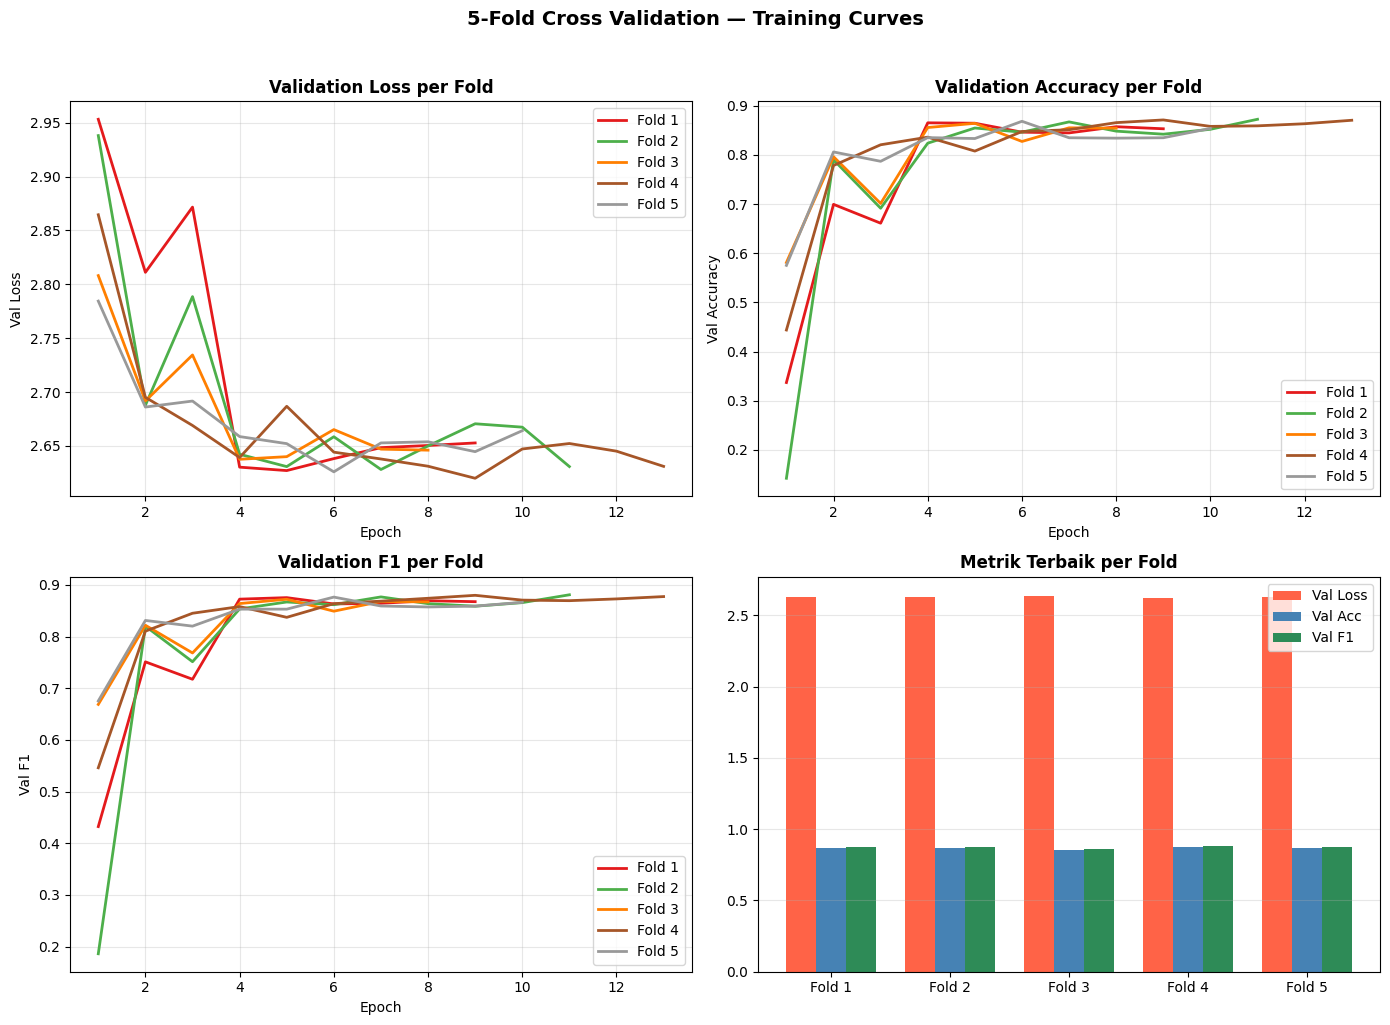

✅ Saved: cv_training_curves.png


In [12]:
# === PLOT TRAINING CURVES UNTUK SEMUA FOLD ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.Set1(np.linspace(0, 1, N_FOLDS))

# Loss
ax = axes[0, 0]
for i, h in enumerate(all_histories):
    ep = range(1, len(h['val_loss']) + 1)
    ax.plot(ep, h['val_loss'], color=colors[i], label=f'Fold {i+1}', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
ax.set_title('Validation Loss per Fold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy
ax = axes[0, 1]
for i, h in enumerate(all_histories):
    ep = range(1, len(h['val_acc']) + 1)
    ax.plot(ep, h['val_acc'], color=colors[i], label=f'Fold {i+1}', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Validation Accuracy per Fold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# F1
ax = axes[1, 0]
for i, h in enumerate(all_histories):
    ep = range(1, len(h['val_f1']) + 1)
    ax.plot(ep, h['val_f1'], color=colors[i], label=f'Fold {i+1}', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val F1')
ax.set_title('Validation F1 per Fold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Bar chart ringkasan
ax = axes[1, 1]
x = np.arange(N_FOLDS)
width = 0.25
ax.bar(x - width, cv_df['val_loss'], width, label='Val Loss', color='tomato')
ax.bar(x, cv_df['val_acc'], width, label='Val Acc', color='steelblue')
ax.bar(x + width, cv_df['val_f1'], width, label='Val F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_title('Metrik Terbaik per Fold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.suptitle('5-Fold Cross Validation — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cv_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cv_training_curves.png")

## 12. Load Model Terbaik & Inferensi 5x di Test Set (TTA)

**Penting:** Kode di bawah ini hanya melakukan **inferensi** (forward pass).
Model **TIDAK di-training ulang**. Yang berubah tiap run hanyalah input (karena augmentasi TTA).

- Run 1: baseline (tanpa augmentasi)
- Run 2–5: dengan TTA (augmentasi ringan)

In [13]:
# === LOAD MODEL TERBAIK ===
checkpoint = torch.load(best_fold_info['model_path'], map_location=device)
model = build_model().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded: {best_fold_info['model_path']}")
print(f"   Fold:     {checkpoint['fold']}")
print(f"   Epoch:    {checkpoint['epoch']}")
print(f"   Val Loss: {checkpoint['val_loss']:.4f}")
print(f"   Val Acc:  {checkpoint['val_acc']:.4f}")
print(f"   Val F1:   {checkpoint['val_f1']:.4f}")

# Dummy criterion untuk fungsi evaluate (tidak dipakai untuk backward)
dummy_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Loaded: /workspace/output_method_b_5fold/models/model_fold4.pth
   Fold:     4
   Epoch:    9
   Val Loss: 2.6200
   Val Acc:  0.8713
   Val F1:   0.8800


In [14]:
# === INFERENSI 5x DI TEST SET ===
print(f"\n{'='*70}")
print(f"🧪 INFERENSI {N_TTA_RUNS}x DI TEST SET — MODEL TERBAIK (Fold {best_fold_info['fold']})")
print(f"{'='*70}")

all_run_probs = []   # (N_TTA_RUNS, N_samples, N_classes)
all_run_preds = []   # (N_TTA_RUNS, N_samples)
all_run_accs = []
true_labels = test_df['label_idx'].values  # ground truth

for run in range(N_TTA_RUNS):
    # Run 1: tanpa augmentasi (baseline)
    # Run 2+: dengan TTA
    if run == 0:
        current_transform = val_test_transform
        label = "baseline (no aug)"
    else:
        current_transform = tta_transform
        label = "TTA"

    print(f"\n🔁 Run {run+1}/{N_TTA_RUNS} — {label}")

    test_dataset = ECGDataset(test_df, transform=current_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    _, run_acc, run_f1, y_true, y_pred, y_probs = evaluate(
        model, test_loader, dummy_criterion, device
    )

    all_run_probs.append(y_probs)
    all_run_preds.append(y_pred)
    all_run_accs.append(run_acc)
    print(f"   Run {run+1} Accuracy: {run_acc:.4f} | F1: {run_f1:.4f}")

all_run_probs = np.array(all_run_probs)   # (N_TTA, N_samples, N_classes)
all_run_preds = np.array(all_run_preds)   # (N_TTA, N_samples)

print(f"\n✅ Selesai {N_TTA_RUNS} run inferensi")
print(f"   Shape probs: {all_run_probs.shape}")


🧪 INFERENSI 5x DI TEST SET — MODEL TERBAIK (Fold 4)

🔁 Run 1/5 — baseline (no aug)


   Run 1 Accuracy: 0.8819 | F1: 0.8884

🔁 Run 2/5 — TTA


   Run 2 Accuracy: 0.8689 | F1: 0.8760

🔁 Run 3/5 — TTA


   Run 3 Accuracy: 0.8686 | F1: 0.8761

🔁 Run 4/5 — TTA


   Run 4 Accuracy: 0.8680 | F1: 0.8753

🔁 Run 5/5 — TTA


   Run 5 Accuracy: 0.8685 | F1: 0.8757

✅ Selesai 5 run inferensi
   Shape probs: (5, 26320, 5)


## 13. Agregasi Hasil 5x Inferensi

3 metode dibandingkan:
- **Single Run**: akurasi run ke-1 (baseline tanpa augmentasi)
- **Soft Voting**: rata-rata probabilitas dari 5 run, lalu argmax
- **Hard Voting**: majority vote dari prediksi 5 run

In [15]:
# === AGREGASI HASIL ===
# Metode 1: Baseline (run pertama, tanpa augmentasi)
baseline_preds = all_run_preds[0]
baseline_probs = all_run_probs[0]
baseline_acc = accuracy_score(true_labels, baseline_preds)
baseline_f1 = f1_score(true_labels, baseline_preds, average='weighted')

# Metode 2: Soft Voting (mean probability)
mean_probs = all_run_probs.mean(axis=0)
soft_preds = mean_probs.argmax(axis=1)
soft_acc = accuracy_score(true_labels, soft_preds)
soft_f1 = f1_score(true_labels, soft_preds, average='weighted')

# Metode 3: Hard Voting (majority vote)
hard_preds, _ = stats.mode(all_run_preds, axis=0, keepdims=False)
hard_acc = accuracy_score(true_labels, hard_preds)
hard_f1 = f1_score(true_labels, hard_preds, average='weighted')

print(f"{'='*70}")
print(f"📊 PERBANDINGAN 3 METODE AGREGASI")
print(f"{'='*70}")
print(f"{'Metode':<25}{'Accuracy':<15}{'F1 Weighted':<15}")
print(f"{'-'*55}")
print(f"{'Single Run (baseline)':<25}{baseline_acc:<15.4f}{baseline_f1:<15.4f}")
print(f"{'Soft Voting (mean)':<25}{soft_acc:<15.4f}{soft_f1:<15.4f}")
print(f"{'Hard Voting (majority)':<25}{hard_acc:<15.4f}{hard_f1:<15.4f}")

# Accuracy per run
print(f"\n📊 Akurasi per run:")
for i, a in enumerate(all_run_accs):
    tag = " (baseline)" if i == 0 else " (TTA)"
    print(f"   Run {i+1}: {a:.4f}{tag}")

# Pilih metode terbaik berdasarkan accuracy
methods = {
    'Single Run (baseline)': (baseline_acc, baseline_preds, baseline_probs),
    'Soft Voting': (soft_acc, soft_preds, mean_probs),
    'Hard Voting': (hard_acc, hard_preds, mean_probs),
}
best_method = max(methods.keys(), key=lambda k: methods[k][0])
test_acc, y_pred_final, y_probs_final = methods[best_method]
y_true_final = true_labels

print(f"\n🏆 METODE TERBAIK: {best_method}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

📊 PERBANDINGAN 3 METODE AGREGASI
Metode                   Accuracy       F1 Weighted    
-------------------------------------------------------
Single Run (baseline)    0.8819         0.8884         
Soft Voting (mean)       0.8835         0.8914         
Hard Voting (majority)   0.8880         0.8927         

📊 Akurasi per run:
   Run 1: 0.8819 (baseline)
   Run 2: 0.8689 (TTA)
   Run 3: 0.8686 (TTA)
   Run 4: 0.8680 (TTA)
   Run 5: 0.8685 (TTA)

🏆 METODE TERBAIK: Hard Voting
   Test Accuracy: 0.8880 (88.80%)


## 14. Final Test Metrics (dengan Metode Terbaik)

In [16]:
# === METRIK LENGKAP DARI METODE TERBAIK ===
test_f1_weighted = f1_score(y_true_final, y_pred_final, average='weighted')
test_f1_macro = f1_score(y_true_final, y_pred_final, average='macro')
precision_weighted = precision_score(y_true_final, y_pred_final, average='weighted')
recall_weighted = recall_score(y_true_final, y_pred_final, average='weighted')
precision_per_class = precision_score(y_true_final, y_pred_final, average=None)
recall_per_class = recall_score(y_true_final, y_pred_final, average=None)
f1_per_class = f1_score(y_true_final, y_pred_final, average=None)

print(f"{'='*60}")
print(f"🎯 FINAL TEST RESULTS — {best_method}")
print(f"{'='*60}")
print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 Weighted:   {test_f1_weighted:.4f}")
print(f"   F1 Macro:      {test_f1_macro:.4f}")
print(f"   Precision:     {precision_weighted:.4f}")
print(f"   Recall:        {recall_weighted:.4f}")

# Per-class metrics
print(f"\n📊 Per-Class Metrics:")
metrics_df = pd.DataFrame({
    'Class': TARGET_CLASSES,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1': f1_per_class,
    'Support': [int(sum(y_true_final == i)) for i in range(NUM_CLASSES)]
}).round(4)
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)

# Classification report
report = classification_report(y_true_final, y_pred_final, target_names=TARGET_CLASSES, digits=4)
print(f"\n📋 Classification Report:")
print(report)
with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)
print("✅ Saved: per_class_metrics.csv, classification_report.txt")

🎯 FINAL TEST RESULTS — Hard Voting
   Accuracy:      0.8880 (88.80%)
   F1 Weighted:   0.8927
   F1 Macro:      0.6621
   Precision:     0.8986
   Recall:        0.8880

📊 Per-Class Metrics:
Class  Precision  Recall     F1  Support
 NORM     0.9674  0.9552 0.9612    18880
  AMI     0.1980  0.4306 0.2712      360
 ASMI     0.8009  0.7818 0.7913     3360
 ILMI     0.5845  0.5362 0.5593      690
  IMI     0.7334  0.7218 0.7275     3030

📋 Classification Report:
              precision    recall  f1-score   support

        NORM     0.9674    0.9552    0.9612     18880
         AMI     0.1980    0.4306    0.2712       360
        ASMI     0.8009    0.7818    0.7913      3360
        ILMI     0.5845    0.5362    0.5593       690
         IMI     0.7334    0.7218    0.7275      3030

    accuracy                         0.8880     26320
   macro avg     0.6568    0.6851    0.6621     26320
weighted avg     0.8986    0.8880    0.8927     26320

✅ Saved: per_class_metrics.csv, classification_r

## 15. Confusion Matrix

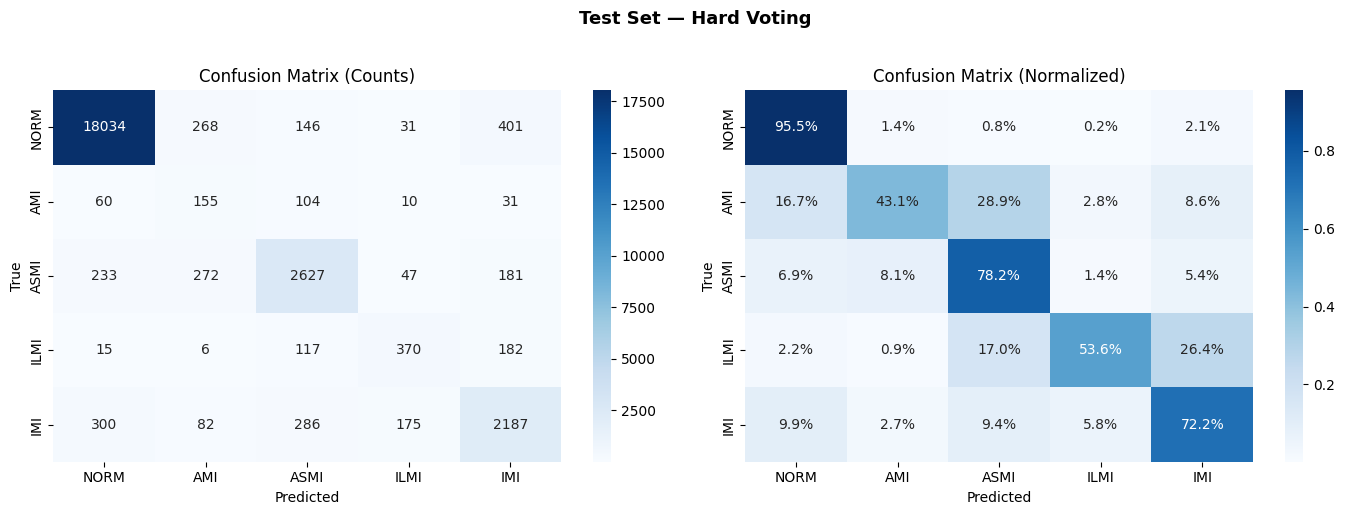

✅ Saved: confusion_matrix.png


In [17]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_true_final, y_pred_final)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle(f'Test Set — {best_method}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

## 16. ROC Curves

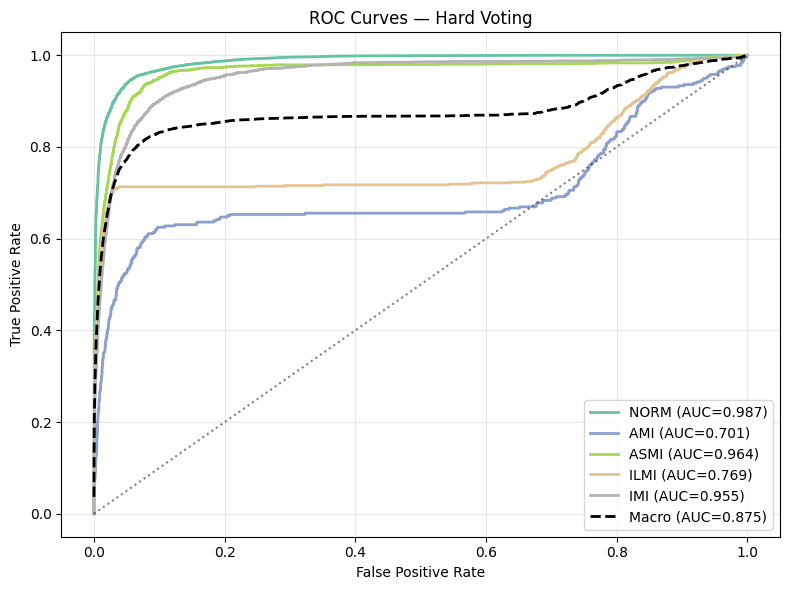


📊 AUC Scores:
   NORM: 0.9867
   AMI: 0.7011
   ASMI: 0.9643
   ILMI: 0.7690
   IMI: 0.9553
   Macro: 0.8753
✅ Saved: roc_curves.png


In [18]:
# === ROC CURVES ===
y_true_bin = label_binarize(y_true_final, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
aucs = []
for i, (cls, color) in enumerate(zip(TARGET_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_final[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')

all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_probs_final[:, i])[0] for i in range(NUM_CLASSES)]))
mean_tpr = np.mean([np.interp(all_fpr, *roc_curve(y_true_bin[:, i], y_probs_final[:, i])[:2]) for i in range(NUM_CLASSES)], axis=0)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro (AUC={macro_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {best_method}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 AUC Scores:")
for cls, a in zip(TARGET_CLASSES, aucs):
    print(f"   {cls}: {a:.4f}")
print(f"   Macro: {macro_auc:.4f}")
print("✅ Saved: roc_curves.png")

## 17. Save All Results

In [19]:
# === SIMPAN HASIL PREDIKSI DI TEST SET ===
test_pred_df = test_df[['image_path', 'ecg_id', 'label', 'label_idx']].copy()
test_pred_df['predicted_idx'] = y_pred_final
test_pred_df['predicted_label'] = [IDX_TO_CLASS[i] for i in y_pred_final]
test_pred_df['correct'] = (y_pred_final == y_true_final)
for i, cls in enumerate(TARGET_CLASSES):
    test_pred_df[f'prob_{cls}'] = y_probs_final[:, i]
test_pred_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)
print("✅ Saved: test_predictions.csv")

# === SIMPAN RESULTS JSON ===
results = {
    'method': 'B - ViT Fine-tuning (5-FOLD CV + TTA)',
    'model': MODEL_NAME,
    'n_folds': N_FOLDS,
    'n_tta_runs': N_TTA_RUNS,
    'best_aggregation_method': best_method,
    'dataset': {
        'total_real': int(len(real_df)),
        'total_synthetic': int(len(synthetic_df)),
        'test_size': int(len(test_df)),
        'trainval_pool': int(len(trainval_real)),
    },
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'max_epochs': NUM_EPOCHS,
        'patience': PATIENCE,
        'lr_backbone': LR_BACKBONE,
        'lr_head': LR_HEAD,
        'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'warmup_epochs': WARMUP_EPOCHS,
    },
    'cv_results': [
        {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
         for k, v in r.items() if k != 'model_path'}
        for r in fold_results
    ],
    'cv_stats': {
        'val_loss_mean': float(cv_df['val_loss'].mean()),
        'val_loss_std': float(cv_df['val_loss'].std()),
        'val_acc_mean': float(cv_df['val_acc'].mean()),
        'val_acc_std': float(cv_df['val_acc'].std()),
        'val_f1_mean': float(cv_df['val_f1'].mean()),
        'val_f1_std': float(cv_df['val_f1'].std()),
    },
    'best_fold': int(best_fold_info['fold']),
    'tta_runs_accuracy': [float(a) for a in all_run_accs],
    'aggregation_comparison': {
        'single_run': {'accuracy': float(baseline_acc), 'f1_weighted': float(baseline_f1)},
        'soft_voting': {'accuracy': float(soft_acc), 'f1_weighted': float(soft_f1)},
        'hard_voting': {'accuracy': float(hard_acc), 'f1_weighted': float(hard_f1)},
    },
    'final_test_results': {
        'accuracy': float(test_acc),
        'f1_weighted': float(test_f1_weighted),
        'f1_macro': float(test_f1_macro),
        'precision': float(precision_weighted),
        'recall': float(recall_weighted),
        'macro_auc': float(macro_auc),
    },
    'per_class': {
        'precision': dict(zip(TARGET_CLASSES, [float(x) for x in precision_per_class])),
        'recall': dict(zip(TARGET_CLASSES, [float(x) for x in recall_per_class])),
        'f1': dict(zip(TARGET_CLASSES, [float(x) for x in f1_per_class])),
        'auc': dict(zip(TARGET_CLASSES, [float(x) for x in aucs])),
    },
    'training_time_total': str(total_train_time),
}
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print("✅ Saved: results.json")

# History semua fold
for i, h in enumerate(all_histories):
    pd.DataFrame(h).to_csv(os.path.join(OUTPUT_DIR, f'history_fold{i+1}.csv'), index=False)
print(f"✅ Saved: history_fold1.csv ... history_fold{N_FOLDS}.csv")

# List semua output
print(f"\n{'='*60}")
print(f"📁 SEMUA FILE DI: {OUTPUT_DIR}")
print(f"{'='*60}")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path) / 1024
        rel = os.path.relpath(path, OUTPUT_DIR)
        print(f"   • {rel} ({size:.1f} KB)")

✅ Saved: test_predictions.csv
✅ Saved: results.json
✅ Saved: history_fold1.csv ... history_fold5.csv

📁 SEMUA FILE DI: /workspace/output_method_b_5fold
   • classification_report.txt (0.5 KB)
   • confusion_matrix.png (114.0 KB)
   • cv_summary.csv (0.7 KB)
   • cv_training_curves.png (254.6 KB)
   • history_fold1.csv (1.2 KB)
   • history_fold2.csv (1.5 KB)
   • history_fold3.csv (1.1 KB)
   • history_fold4.csv (1.7 KB)
   • history_fold5.csv (1.3 KB)
   • per_class_metrics.csv (0.2 KB)
   • results.json (3.3 KB)
   • roc_curves.png (109.1 KB)
   • test_predictions.csv (3730.8 KB)
   • models/model_fold1.pth (336005.0 KB)
   • models/model_fold2.pth (336005.0 KB)
   • models/model_fold3.pth (336005.0 KB)
   • models/model_fold4.pth (336005.0 KB)
   • models/model_fold5.pth (336005.0 KB)


## 18. Final Summary

In [20]:
# === FINAL SUMMARY ===
print(f"\n{'='*70}")
print(f"🎉 METODE B (5-FOLD CV + TTA) SELESAI!")
print(f"{'='*70}")

print(f"\n📋 Model: {MODEL_NAME}")
print(f"   Strategi: 5-Fold Patient-wise CV + TTA {N_TTA_RUNS}x")

print(f"\n📊 CV Results (5 folds):")
print(f"   Val Loss: {cv_df['val_loss'].mean():.4f} ± {cv_df['val_loss'].std():.4f}")
print(f"   Val Acc:  {cv_df['val_acc'].mean():.4f} ± {cv_df['val_acc'].std():.4f}")
print(f"   Val F1:   {cv_df['val_f1'].mean():.4f} ± {cv_df['val_f1'].std():.4f}")

print(f"\n🏆 Best Fold: {best_fold_info['fold']} (Val Loss: {best_fold_info['val_loss']:.4f})")

print(f"\n🧪 TTA Inference ({N_TTA_RUNS} runs):")
print(f"   Baseline Acc:    {baseline_acc:.4f}")
print(f"   Soft Voting Acc: {soft_acc:.4f}")
print(f"   Hard Voting Acc: {hard_acc:.4f}")
print(f"   🎯 Method Dipakai: {best_method}")

print(f"\n🎯 FINAL TEST RESULTS:")
print(f"   Accuracy:    {test_acc*100:.2f}%")
print(f"   F1 Weighted: {test_f1_weighted:.4f}")
print(f"   F1 Macro:    {test_f1_macro:.4f}")
print(f"   Macro AUC:   {macro_auc:.4f}")

print(f"\n📈 Per-Class F1:")
for c, fv in zip(TARGET_CLASSES, f1_per_class):
    bar = '█' * int(fv * 30)
    print(f"   {c:6s}: {fv:.4f} {bar}")

print(f"\n⏱️  Total training time: {total_train_time}")
print(f"📁 Output: {OUTPUT_DIR}")
print("="*70)


🎉 METODE B (5-FOLD CV + TTA) SELESAI!

📋 Model: google/vit-base-patch16-224
   Strategi: 5-Fold Patient-wise CV + TTA 5x

📊 CV Results (5 folds):
   Val Loss: 2.6278 ± 0.0064
   Val Acc:  0.8655 ± 0.0059
   Val F1:   0.8746 ± 0.0061

🏆 Best Fold: 4 (Val Loss: 2.6200)

🧪 TTA Inference (5 runs):
   Baseline Acc:    0.8819
   Soft Voting Acc: 0.8835
   Hard Voting Acc: 0.8880
   🎯 Method Dipakai: Hard Voting

🎯 FINAL TEST RESULTS:
   Accuracy:    88.80%
   F1 Weighted: 0.8927
   F1 Macro:    0.6621
   Macro AUC:   0.8753

📈 Per-Class F1:
   NORM  : 0.9612 ████████████████████████████
   AMI   : 0.2712 ████████
   ASMI  : 0.7913 ███████████████████████
   ILMI  : 0.5593 ████████████████
   IMI   : 0.7275 █████████████████████

⏱️  Total training time: 4:24:31.830937
📁 Output: /workspace/output_method_b_5fold
